# Data Preprocessing and Feature Extraction with SIFT


## Part 1: Data Exploration

We start by exploring `migdal_1_sift_dataset.csv` to understand the structure of the data.

Each row represents a SIFT keypoint with:
- (X, Y) coordinates
- Scale (feature size)
- Angle (feature orientation)
- Response (strength of keypoint)
- 128 SIFT feature descriptors (Feature_1 to Feature_128)

We plot statistics and visualize the keypoints to ensure that feature extraction was successful.


In [652]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load the dataset
sift_df = pd.read_csv("migdal_1_sift_dataset.csv")
sift_df2 = pd.read_csv("migdal_2_sift_dataset.csv")

sift_df.head()


,Y,X,Scale,Angle,Response,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,...,Feature_119,Feature_120,Feature_121,Feature_122,Feature_123,Feature_124,Feature_125,Feature_126,Feature_127,Feature_128
0,1080.289917,1871.340576,2.650851,265.588531,0.108878,133.0,26.0,0.0,1.0,1.0,...,28.0,25.0,4.0,3.0,2.0,2.0,46.0,4.0,0.0,2.0
1,992.686340,1960.387939,2.606995,353.797394,0.077875,30.0,23.0,31.0,1.0,0.0,...,71.0,84.0,4.0,97.0,60.0,0.0,0.0,22.0,10.0,1.0
2,1958.299438,2614.439209,17.619907,261.920410,0.076401,2.0,1.0,5.0,10.0,5.0,...,28.0,61.0,2.0,1.0,9.0,14.0,71.0,83.0,9.0,3.0
3,1485.067261,1269.294067,2.251461,267.496582,0.086173,129.0,42.0,3.0,13.0,24.0,...,9.0,41.0,24.0,2.0,0.0,0.0,0.0,0.0,0.0,16.0
4,1375.478271,2610.739746,2.060762,218.360001,0.080922,70.0,131.0,8.0,11.0,7.0,...,6.0,13.0,7.0,1.0,1.0,7.0,2.0,0.0,0.0,8.0


In [653]:
sift_df.describe()

,Y,X,Scale,Angle,Response,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,...,Feature_119,Feature_120,Feature_121,Feature_122,Feature_123,Feature_124,Feature_125,Feature_126,Feature_127,Feature_128
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1471.882879,2052.321515,6.415403,183.120681,0.075678,22.510000,17.636000,19.375000,13.403000,19.254000,...,17.336000,25.769000,21.548000,15.811000,17.140000,13.055000,22.279000,12.343000,11.317000,11.22400
std,572.609704,819.846173,9.453957,100.941190,0.008718,32.354795,26.402246,31.183373,22.650378,30.198202,...,26.722635,30.569824,28.635322,25.579163,31.080483,22.105217,34.052999,22.558507,23.081752,19.85679
min,33.511398,32.151867,1.802956,0.071983,0.066234,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,962.038513,1459.857513,2.508220,91.655151,0.069203,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,4.000000,2.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.00000
50%,1473.780640,1924.157227,3.352797,181.275871,0.073077,9.000000,7.000000,5.000000,5.000000,5.500000,...,6.000000,14.000000,10.000000,5.000000,3.000000,4.000000,6.000000,3.000000,2.000000,3.00000
75%,1918.500000,2597.100159,5.483221,267.870743,0.079520,29.000000,21.000000,23.000000,15.000000,24.000000,...,23.000000,38.000000,30.000000,18.000000,16.000000,14.000000,27.000000,13.000000,10.000000,12.00000
max,2980.874512,3960.908936,107.784523,359.909546,0.114931,159.000000,154.000000,155.000000,142.000000,160.000000,...,138.000000,152.000000,151.000000,168.000000,162.000000,132.000000,149.000000,158.000000,138.000000,134.00000


#####  Exploring Keypoint Attribute Distributions

We used four histograms to show the distribution of keypoint attributes from the SIFT dataset:

- We used the first plot to show Response values for each keypoint, which reflect how distinctive or stable a keypoint is.

- We used the second plot to show the Scale of keypoints, indicating the relative size of the region around each keypoint.

- We used the third plot to show Feature_1, one of the 128 SIFT descriptor values, to understand how descriptor components are distributed.

- We used the fourth plot to show Feature_10, another SIFT descriptor dimension, to further explore variation in descriptor values.

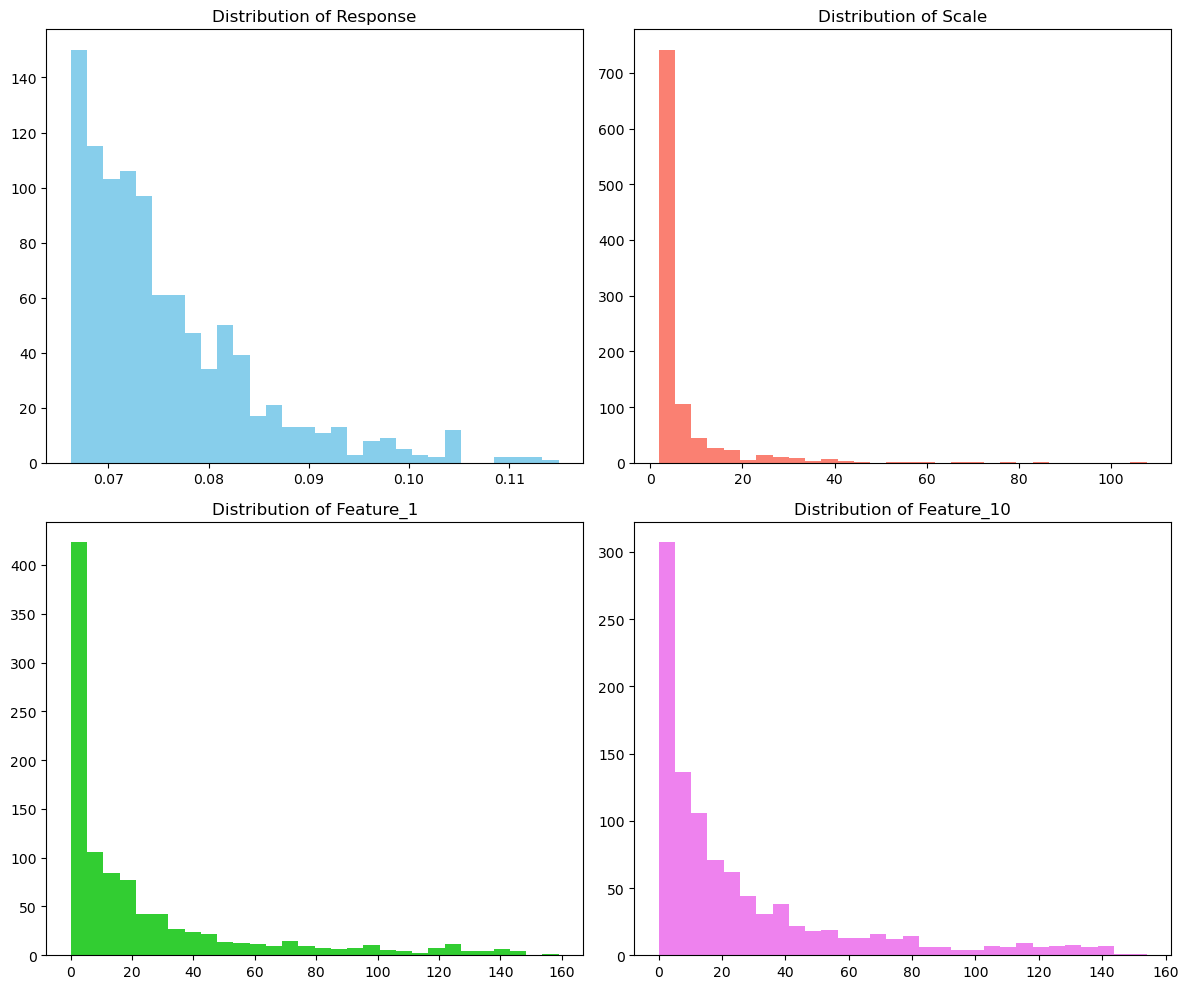

In [655]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(sift_df["Response"], bins=30, color='skyblue')
axes[0, 0].set_title("Distribution of Response")

axes[0, 1].hist(sift_df["Scale"], bins=30, color='salmon')
axes[0, 1].set_title("Distribution of Scale")

axes[1, 0].hist(sift_df["Feature_1"], bins=30, color='limegreen')
axes[1, 0].set_title("Distribution of Feature_1")

axes[1, 1].hist(sift_df["Feature_10"], bins=30, color='violet')
axes[1, 1].set_title("Distribution of Feature_10")

plt.tight_layout()
plt.show()

##### Visualizing SIFT Keypoints with Scale and Orientation
We used this plot to visualize SIFT keypoints from the migdal_1.JPG image by combining both scale and orientation:

- We used cyan circles to represent each keypoint’s position and scale. The radius of each circle is proportional to the keypoint’s Scale value.

- We used magenta arrows to show the orientation of each keypoint, computed from the Angle column and scaled by the keypoint's size.

This combined visualization helps us understand not only where features are detected and how large they are, but also the direction they are facing — all of which are crucial for matching and alignment tasks in image processing.

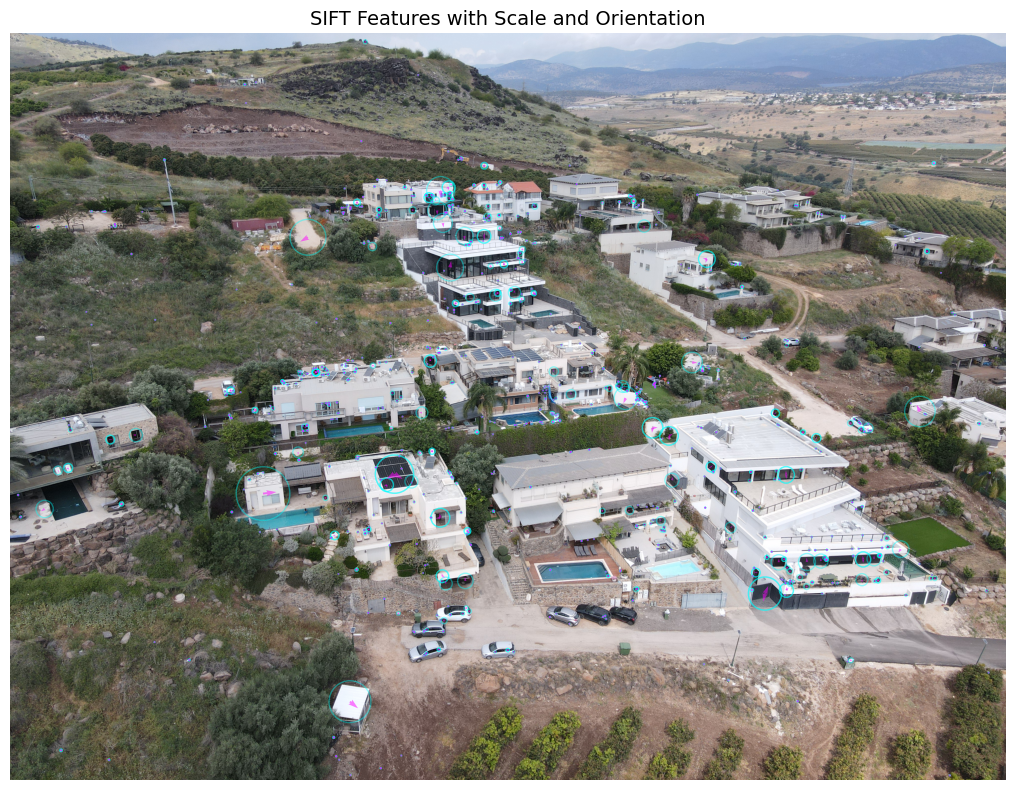

In [657]:
img = Image.open("migdal_1.JPG")
img2 = Image.open("migdal_2.JPG")

x = sift_df['X'].values
y = sift_df['Y'].values
scale = sift_df['Scale'].values
angle = sift_df['Angle'].values

angle_rad = np.deg2rad(angle)

u = np.cos(angle_rad) * scale * 0.5
v = np.sin(angle_rad) * scale * 0.5

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

for xi, yi, si in zip(x, y, scale):
    circle = plt.Circle((xi, yi), radius=si, color='cyan', fill=False, linewidth=1, alpha=0.4)
    ax.add_patch(circle)

ax.quiver(
    x, y, u, v,
    color='magenta',
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.002,
    alpha=0.5
)

ax.set_title("SIFT Features with Scale and Orientation", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


### Part A: Model Implementation

We start by implementing a brute-force K-Nearest Neighbors (KNN) model using linear search.
This model stores all training points and computes exact distances at query time using vectorized numpy operations.


In [659]:

class KNN:
    def __init__(self):
        self.X_train = None

    def fit(self, X):
        """
        Store the training set.
        """
        self.X_train = X

    def kneighbors(self, X_query, k=1):
        """
        Return the indices and distances of the k-nearest neighbors for each point in X_query.
        Uses Euclidean distance and vectorized computation.
        """
        # Compute pairwise distances: shape (num_queries, num_train)
        distances = np.sqrt(((X_query[:, None, :] - self.X_train[None, :, :]) ** 2).sum(axis=2))
        
        # Get indices of k smallest distances
        nearest_indices = np.argsort(distances, axis=1)[:, :k]
        nearest_distances = np.take_along_axis(distances, nearest_indices, axis=1)
        
        return nearest_indices, nearest_distances


We now apply our custom KNN implementation to find the 2 nearest neighbors for each keypoint in the second image (`sift_df2`) using descriptors from the first image (`sift_df`) as the training set.

We extract only the 128 SIFT feature columns (ignoring X, Y, Scale, etc.), fit the model, and retrieve the neighbor indices and distances. This serves as our ground-truth reference for later comparisons with approximate methods.


In [661]:
knn = KNN()
X_train = sift_df.iloc[:, 5:].values
X_test = sift_df2.iloc[:, 5:].values
knn.fit(X_train)

indices, distances = knn.kneighbors(X_test, k=2)
print("Indices of nearest neighbors:", indices[:5])
print("Distances to nearest neighbors:", distances[:5])


Indices of nearest neighbors: [[823 756]
 [ 77 151]
 [ 22   0]
 [188 151]
 [157 883]]
Distances to nearest neighbors: [[188.50198938 267.29010457]
 [324.99846153 339.25948771]
 [213.10091506 225.        ]
 [316.56436944 317.60824926]
 [336.12497676 343.11951271]]




#### We define an abstract base class `ANNBase` for all Approximate Nearest Neighbor models.
#### This class enforces the structure of implementing `fit()` and `kneighbors()` methods.



In [663]:
from abc import ABC, abstractmethod
import numpy as np

class ANNBase(ABC):
    def __init__(self):
        self.X_train = None

    def fit(self, X):
        """
        Store the training set.
        """
        self.X_train = X

    @abstractmethod
    def kneighbors(self, X_query, k=1):
        """
        Abstract method to be implemented in child classes.
        Should return indices and distances of k nearest neighbors.
        """
        pass


### LSH_ANN – Locality-Sensitive Hashing for Approximate Nearest Neighbors
We implement `LSH_ANN`, an approximate nearest neighbor model based on Locality-Sensitive Hashing. It builds L hash tables, each using K random hyperplanes to bucket similar points. Querying retrieves candidates from these hash buckets, followed by exact distance-based filtering.

Like RKDT_ANN, it includes optional ratio tests, response filtering, percentile-based distance filtering, and label voting for classification tasks.

In [665]:
from collections import Counter

class LSH_ANN(ANNBase):
    def __init__(self, K=10, L=5):
        super().__init__()
        self.K = K
        self.L = L
        self.hash_tables = []
        self.random_vectors = []

    def _hash(self, x, rv):
        return tuple((rv @ x.T > 0).astype(int))

    def fit(self, X):
        self.X_train = X
        D = X.shape[1]
        for _ in range(self.L):
            rv = np.random.randn(self.K, D)
            table = {}
            for idx, x in enumerate(X):
                h = self._hash(x, rv)
                if h not in table:
                    table[h] = []
                table[h].append(idx)
            self.hash_tables.append(table)
            self.random_vectors.append(rv)

    def kneighbors(self, X_query, k=1):
        results_indices = []
        results_distances = []
        for q in X_query:
            candidates = set()
            for rv, table in zip(self.random_vectors, self.hash_tables):
                h = self._hash(q, rv)
                if h in table:
                    candidates.update(table[h])
            if not candidates:
                distances = np.linalg.norm(self.X_train - q, axis=1)
                nearest = np.argsort(distances)[:k]
            else:
                candidate_vectors = self.X_train[list(candidates)]
                distances = np.linalg.norm(candidate_vectors - q, axis=1)
                sorted_indices = np.argsort(distances)[:k]
                nearest = np.array(list(candidates))[sorted_indices]
            true_distances = np.linalg.norm(self.X_train[nearest] - q, axis=1)
            results_indices.append(nearest)
            results_distances.append(true_distances)
        return np.array(results_indices, dtype=object), np.array(results_distances, dtype=object)

    

    def predict(self, X_query, y_train_labels, PREDICT_PARAMS, response_scores=None):
        # === Extract Params ===
        k = PREDICT_PARAMS.get("k", 2)
        dist_pct = PREDICT_PARAMS.get("distance_percentile", None)
        response_thresh = PREDICT_PARAMS.get("response_threshold", 0.0)
        top_fraction = PREDICT_PARAMS.get("top_response_fraction", 1.0)
        min_vote_ratio = PREDICT_PARAMS.get("min_vote_ratio", 0.0)
        conf_thresh = PREDICT_PARAMS.get("confidence_min_threshold", 0.0)
        exclude_labels = PREDICT_PARAMS.get("exclude_labels", set())
        ratio_thresh = PREDICT_PARAMS.get("ratio_thresh", None)
        verbose = PREDICT_PARAMS.get("verbose", False)

        # === Step 1: Optional filtering by response scores ===
        if response_scores is not None:
            if response_thresh > 0:
                mask = response_scores >= response_thresh
                X_query = X_query[mask]
                response_scores = response_scores[mask]
            if top_fraction < 1.0:
                top_k = int(len(response_scores) * top_fraction)
                top_indices = np.argsort(response_scores)[::-1][:top_k]
                X_query = X_query[top_indices]

        elif top_fraction < 1.0:
            norms = np.linalg.norm(X_query, axis=1)
            top_k = int(len(norms) * top_fraction)
            top_indices = np.argsort(norms)[::-1][:top_k]
            X_query = X_query[top_indices]

        if len(X_query) == 0:
            return "no_match", 0.0

        predictions = []
        distances_collected = []

        for q in X_query:
            indices, dists = self.kneighbors(np.array([q]), k=2)
            if len(indices[0]) < 2:
                continue

            d1, d2 = dists[0][:2]
            if ratio_thresh is not None and d2 > 0 and d1 / d2 >= ratio_thresh:
                continue
            distances_collected.append(d1)

            label = y_train_labels[indices[0][0]]
            if label in exclude_labels:
                continue

            predictions.append(label)

        if not predictions:
            return "no_match", 0.0

        # === Step 2: Percentile-based distance filtering ===
        if dist_pct is not None and len(distances_collected) > 0:
            dist_threshold = np.percentile(distances_collected, dist_pct)
            valid_preds = []
            for i, d in enumerate(distances_collected):
                if d <= dist_threshold:
                    valid_preds.append(predictions[i])
            predictions = valid_preds

        if not predictions:
            return "no_match", 0.0
        

        # === Step 3: Final voting ===
        vote_counts = Counter(predictions)
        final_label, votes = vote_counts.most_common(1)[0]
        confidence = votes / len(predictions)
        vote_ratio = votes / len(X_query)

        if confidence < conf_thresh or vote_ratio < min_vote_ratio:
            return "no_match", confidence

        if verbose:
            print(f"Votes: {vote_counts}, Label: {final_label}, Conf: {confidence:.2f}, Ratio: {vote_ratio:.2f}")

        return final_label, confidence


In [666]:
lsh = LSH_ANN(K=10, L=5)
lsh.fit(X_train)

indices, distances = lsh.kneighbors(X_test, k=2)
print("ANN Nearest indices:", indices[:5])
print("ANN distances:", distances[:5])


ANN Nearest indices: [[823 756]
 [100 614]
 [22 0]
 [921 12]
 [143 76]]
ANN distances: [[188.50198937942272 267.2901045680517]
 [346.5198407017988 359.74296379498514]
 [213.10091506138588 225.0]
 [358.949857222426 385.3414070665129]
 [351.6091580149755 358.44664874985233]]


#### RKDT_ANN – Random KD-Tree Based Approximate Nearest Neighbor
We implement `RKDT_ANN`, which builds L random KD-Trees to approximate nearest neighbor search. Each tree recursively splits the dataset using random dimensions. During querying, the model searches the leaf nodes of all trees and returns the k-nearest neighbors from the combined candidates.

The model also supports Lowe's ratio test, response-based filtering, percentile filtering, and majority voting for robust place recognition.

In [668]:
import numpy as np
from collections import Counter

class RKDT_ANN(ANNBase):
    def __init__(self, N0=10, L0=5):
        super().__init__()
        self.N0 = N0
        self.L0 = L0
        self.trees = []

    def fit(self, X):
        self.X_train = X
        for _ in range(self.L0):
            indices = np.arange(X.shape[0])
            tree = self._build_tree(X, indices)
            self.trees.append(tree)

    def _build_tree(self, X, indices):
        if len(indices) <= self.N0:
            return {'leaf': True, 'indices': indices}
        dim = np.random.randint(X.shape[1])
        median = np.median(X[indices, dim])
        left = indices[X[indices, dim] <= median]
        right = indices[X[indices, dim] > median]
        return {
            'leaf': False,
            'dim': dim,
            'median': median,
            'left': self._build_tree(X, left),
            'right': self._build_tree(X, right)
        }

    def _search_tree(self, tree, query):
        while not tree['leaf']:
            dim = tree['dim']
            if query[dim] <= tree['median']:
                tree = tree['left']
            else:
                tree = tree['right']
        return tree['indices']

    def kneighbors(self, X_query, k=1):
        results_indices = []
        results_distances = []
        for q in X_query:
            candidates = set()
            for tree in self.trees:
                leaf_indices = self._search_tree(tree, q)
                candidates.update(leaf_indices)
            if not candidates:
                distances = np.linalg.norm(self.X_train - q, axis=1)
                nearest = np.argsort(distances)[:k]
            else:
                candidate_vectors = self.X_train[list(candidates)]
                distances = np.linalg.norm(candidate_vectors - q, axis=1)
                sorted_indices = np.argsort(distances)[:k]
                nearest = np.array(list(candidates))[sorted_indices]
            true_distances = np.linalg.norm(self.X_train[nearest] - q, axis=1)
            results_indices.append(nearest)
            results_distances.append(true_distances)
        return np.array(results_indices, dtype=object), np.array(results_distances, dtype=object)

    def predict(self, X_query, y_train_labels, PREDICT_PARAMS, response_scores=None):
        # === Extract Params ===
        k = PREDICT_PARAMS.get("k", 2)
        threshold = PREDICT_PARAMS.get("threshold", None)
        ratio_thresh = PREDICT_PARAMS.get("ratio_thresh", None)
        dist_pct = PREDICT_PARAMS.get("distance_percentile", None)
        response_thresh = PREDICT_PARAMS.get("response_threshold", 0.0)
        top_fraction = PREDICT_PARAMS.get("top_response_fraction", 1.0)
        min_vote_ratio = PREDICT_PARAMS.get("min_vote_ratio", 0.0)
        conf_thresh = PREDICT_PARAMS.get("confidence_min_threshold", 0.0)
        exclude_labels = PREDICT_PARAMS.get("exclude_labels", set())
        verbose = PREDICT_PARAMS.get("verbose", False)

        # === Step 1: Filter by response scores ===
        if response_scores is not None:
            if response_thresh > 0:
                mask = response_scores >= response_thresh
                X_query = X_query[mask]
                response_scores = response_scores[mask]
            if top_fraction < 1.0:
                top_k = int(len(response_scores) * top_fraction)
                top_indices = np.argsort(response_scores)[::-1][:top_k]
                X_query = X_query[top_indices]
        elif top_fraction < 1.0:
            norms = np.linalg.norm(X_query, axis=1)
            top_k = int(len(norms) * top_fraction)
            top_indices = np.argsort(norms)[::-1][:top_k]
            X_query = X_query[top_indices]

        if len(X_query) == 0:
            return "no_match", 0.0

        predictions = []
        distances_collected = []

        for q in X_query:
            indices, dists = self.kneighbors(np.array([q]), k=2)
            if len(indices[0]) < 2:
                continue

            d1, d2 = dists[0][:2]

            # 🔹 Hard distance threshold
            if threshold is not None and d1 > threshold:
                continue

            # 🔹 Ratio test
            if ratio_thresh is not None and d2 > 0 and d1 / d2 >= ratio_thresh:
                continue

            distances_collected.append(d1)

            label = y_train_labels[indices[0][0]]
            if label in exclude_labels:
                continue

            predictions.append(label)

        if not predictions:
            return "no_match", 0.0

        # === Step 2: Distance percentile filter
        if dist_pct is not None and len(distances_collected) > 0:
            dist_threshold = np.percentile(distances_collected, dist_pct)
            valid_preds = []
            for i, d in enumerate(distances_collected):
                if d <= dist_threshold:
                    valid_preds.append(predictions[i])
            predictions = valid_preds

        if not predictions:
            return "no_match", 0.0

        # === Step 3: Final voting
        vote_counts = Counter(predictions)
        final_label, votes = vote_counts.most_common(1)[0]
        confidence = votes / len(predictions)
        vote_ratio = votes / len(X_query)

        if confidence < conf_thresh or vote_ratio < min_vote_ratio:
            return "no_match", confidence

        if verbose:
            print(f"Votes: {vote_counts}, Label: {final_label}, Conf: {confidence:.2f}, Ratio: {vote_ratio:.2f}")

        return final_label, confidence


In [669]:
rkdt = RKDT_ANN(N0=10, L0=5)
rkdt.fit(X_train)

indices, distances = rkdt.kneighbors(X_test, k=2)
print("RKDT Nearest indices:", indices[:5])
print("RKDT distances:", distances[:5])


RKDT Nearest indices: [[563 752]
 [171 43]
 [22 0]
 [60 36]
 [883 472]]
RKDT distances: [[282.95052571076803 295.80567945866085]
 [411.89319003838847 422.7398727349953]
 [213.10091506138588 225.0]
 [357.659055526349 381.67132457128605]
 [343.1195127065787 368.6502407431738]]


##### We define a utility function `evaluate_model()` to measure both runtime and approximation accuracy (ε) of any ANN model.

- It compares the ANN's distance results to the exact KNN baseline using `ε = mean(d_ANN / d_KNN)`.
- It also prints the model's runtime for `kneighbors()`.
- This helps us quickly benchmark and compare models like LSH and RKDT.


In [671]:
import time

def evaluate_model(model, model_name):
    start = time.time()
    indices_ann, distances_ann = model.kneighbors(X_test, k=1)
    runtime = time.time() - start

    _, distances_knn = knn.kneighbors(X_test, k=1)
    epsilon = np.mean(distances_ann.flatten() / distances_knn.flatten())

    print(f"{model_name} runtime: {runtime:.4f} seconds")
    print(f"{model_name} approximation error ε: {epsilon:.4f}")


In [672]:
evaluate_model(knn, "KNN (Exact)")
evaluate_model(lsh, "LSH_ANN")
evaluate_model(rkdt, "RKDT_ANN")


KNN (Exact) runtime: 2.5571 seconds
KNN (Exact) approximation error ε: 1.0000
LSH_ANN runtime: 0.6445 seconds
LSH_ANN approximation error ε: 1.0528
RKDT_ANN runtime: 0.3876 seconds
RKDT_ANN approximation error ε: 1.1112


### Part B: Visualizing Top 10 Matched Keypoints

We use our custom KNN implementation to find the closest keypoints between `migdal_2` (query image) and `migdal_1` (reference image), using Euclidean distance on the SIFT descriptors.

The top 10 matches (i.e., those with the smallest distances) are visualized on a side-by-side stitched image:
- Each match is shown as a colored line connecting corresponding keypoints across the two images.
- Matching keypoints are also highlighted with colored circles at their (X, Y) positions.

This visualization helps verify the quality of nearest neighbor retrieval based on descriptor similarity.


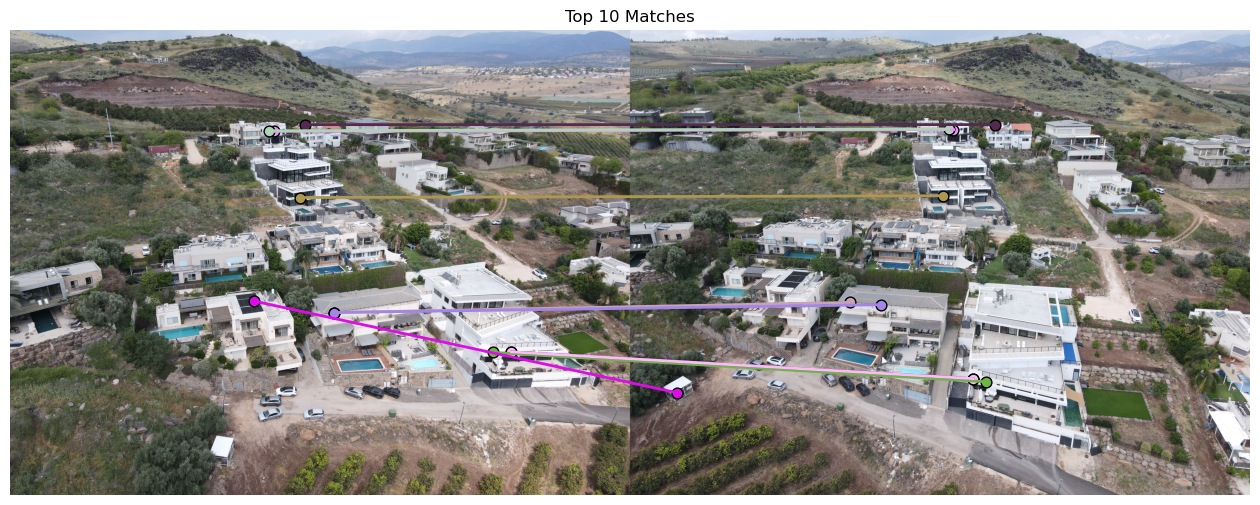

In [674]:
img1_np = np.array(img)
img2_np = np.array(img2)

stitched_img = np.hstack((img1_np, img2_np))

X_train = sift_df.iloc[:, 5:].values
X_test = sift_df2.iloc[:, 5:].values

knn = KNN()
knn.fit(X_train)
indices, distances = knn.kneighbors(X_test, k=1)

top_10 = np.argsort(distances.flatten())[:10]

x1 = sift_df.iloc[indices[top_10].flatten()][['X', 'Y']].values
x2 = sift_df2.iloc[top_10][['X', 'Y']].values

x2[:, 0] += img1_np.shape[1]  # shift x of right image

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(stitched_img)
ax.set_title("Top 10 Matches")

for i in range(10):
    color = np.random.rand(3,)
    ax.plot([x1[i, 0], x2[i, 0]], [x1[i, 1], x2[i, 1]], color=color, linewidth=2)
    ax.scatter(x1[i, 0], x1[i, 1], color=color, s=60, edgecolor='black')
    ax.scatter(x2[i, 0], x2[i, 1], color=color, s=60, edgecolor='black')

ax.axis('off')
plt.show()

### Part C: Hyperparameter Tuning and Data Preparation

We begin by loading the SIFT feature datasets for the training (`migdal_1`) and test (`migdal_2`) images.

We extract the 128-dimensional SIFT descriptors from each dataset and normalize them using L2 normalization. This normalization ensures that distance calculations (e.g., Euclidean) are meaningful and comparable.

Next, we will vary the hyperparameters of our approximate nearest neighbor models:

- For LSH_ANN: number of cuts `K` and number of hash tables `L`
- For RKDT_ANN: maximum points per leaf `N0` and number of trees `L0`

Our goal is to evaluate how these parameters affect both the runtime and the approximation error ε, defined as the mean ratio of approximate to exact nearest neighbor distances.


In [676]:
from sklearn.neighbors import NearestNeighbors

df_train = pd.read_csv("migdal_1_sift_dataset.csv")
df_test = pd.read_csv("migdal_2_sift_dataset.csv")

X_train = df_train[[col for col in df_train.columns if "Feature_" in col]].values
X_test = df_test[[col for col in df_test.columns if "Feature_" in col]].values

X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)


### Exact Nearest Neighbor Search and Ratio Test Preparation

We use `sklearn`’s brute-force `NearestNeighbors` with `k=2` to find the two closest neighbors for each test keypoint based on exact Euclidean distances.

This provides the ground truth distances and indices against which we compare approximate methods later.

Before applying Lowe’s ratio test, we perform a **sanity check** to understand the distance distribution:

- We print the minimum exact distance to verify distances are reasonable.
- We check for any zero distances in the second nearest neighbors, which may indicate duplicate or identical keypoints.

Zero distances are important to detect because they can cause division by zero or skew the ratio test results, so identifying them early helps us handle these edge cases correctly.

The `apply_ratio_test` function implements Lowe’s ratio test to filter matches where the ratio between the closest and second-closest neighbor distances is below a threshold (default 0.8).

The `compute_error` function calculates the average ratio error between approximate and exact distances, ignoring cases where exact distances are near zero to avoid instability.


In [678]:
knn_exact = NearestNeighbors(n_neighbors=2, algorithm='brute').fit(X_train)
dists_knn, indices_knn = knn_exact.kneighbors(X_test, n_neighbors=2)

print("Min exact distance:", np.min(dists_knn))
print("Zero distances at indices:", np.where(dists_knn[:, 1] == 0)[0])

def apply_ratio_test(dists, indices, threshold=0.8):
    accepted_indices = []
    for i in range(len(dists)):
        if len(dists[i]) < 2:
            continue
        d1, d2 = dists[i][:2]
        if d2 == 0:
            continue
        if d1 / d2 < threshold:
            accepted_indices.append(indices[i][0])
        else:
            accepted_indices.append(None)
    return accepted_indices

def compute_error(approx_dists, exact_dists):
    approx_dists = np.array(approx_dists)
    exact_dists = np.array(exact_dists)
    mask = exact_dists > 1e-6
    return np.mean(approx_dists[mask] / exact_dists[mask])


Min exact distance: 0.11297910287458042
Zero distances at indices: []


We added hyperparameter tuning for both LSH_ANN and RKDT_ANN to evaluate how their key parameters affect performance.

We vary:
- `K` and `L` for LSH_ANN (number of cuts and hash tables)
- `N0` and `L0` for RKDT_ANN (leaf size and number of trees)

To ensure consistent and reproducible results during randomized tree/hash construction, we set `np.random.seed(42)` before training.

We measure runtime and approximation error for each configuration to understand the trade-offs between speed and accuracy.

Finally, we visualize the results with 3D scatter plots to compare how runtime and error change with different hyperparameter settings.


  Models   K  L  Runtime (s)     Error
0    LSH  17  2     0.551300  0.004753
1    LSH  16  2     0.578227  0.004366
2    LSH  18  1     0.844072  0.004151
3    LSH  19  3     0.709646  0.004418
4    LSH  15  4     0.531926  0.004784
  Models  N0  L0  Runtime (s)     Error
0   RKDT   2   5     0.694483  0.004566
1   RKDT   2  10     1.383587  0.004414
2   RKDT   2  15     1.766459  0.004051
3   RKDT   2  20     2.130191  0.004066
4   RKDT   2  25     2.497263  0.003980


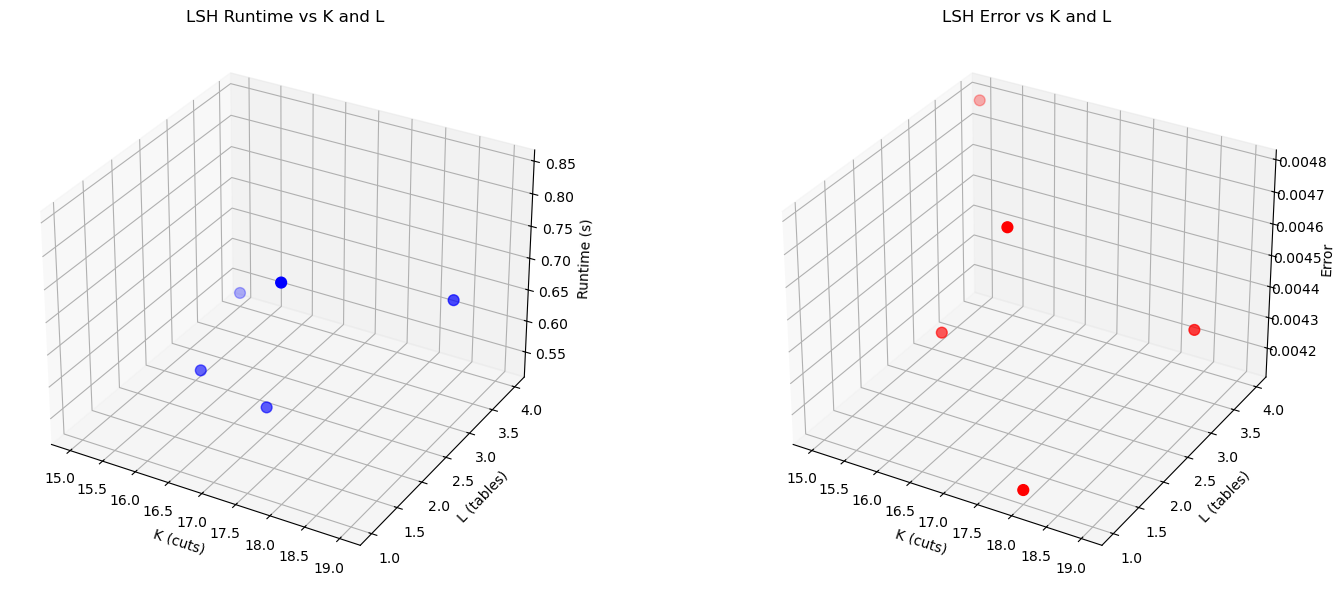

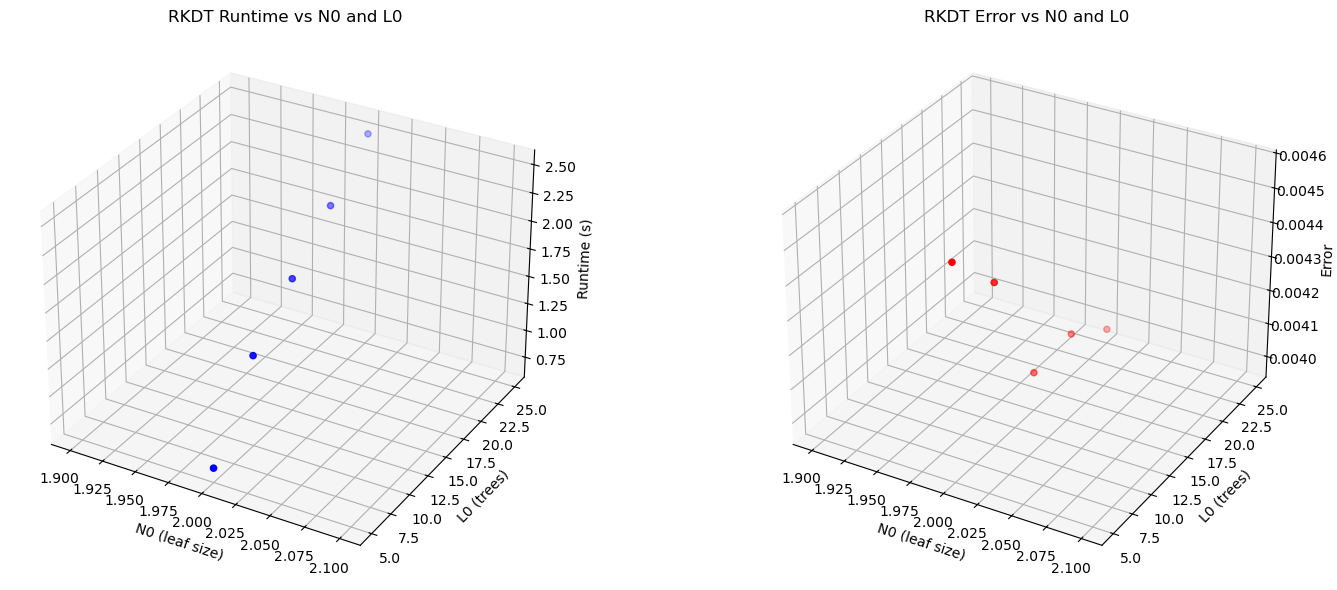

In [680]:
np.random.seed(42)
X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

knn_exact = NearestNeighbors(n_neighbors=2, algorithm='brute').fit(X_train)
_, dists_knn = knn_exact.kneighbors(X_test, n_neighbors=2)


lsh_configs = [(17, 2), (16, 2), (18, 1), (19, 3), (15, 4)]
results = []

for K, L in lsh_configs:
    model = LSH_ANN(K=K, L=L)
    start = time.time()
    model.fit(X_train)
    indices, dists = model.kneighbors(X_test, k=2)
    runtime = time.time() - start

    approx_dists = np.array([d[0] for d in dists])
    exact_dists = np.array([d[0] for d in dists_knn])
    error = compute_error(approx_dists, exact_dists)

    results.append(("LSH", K, L, runtime, error))

df_results = pd.DataFrame(results, columns=["Models", "K", "L", "Runtime (s)", "Error"])
print(df_results)


rkdt_configs = [(2, 5), (2, 10), (2, 15), (2, 20), (2, 25)]
results_RKDT = []

for N0, L0 in rkdt_configs:
    model = RKDT_ANN(N0=N0, L0=L0)
    start = time.time()
    model.fit(X_train)
    indices, dists = model.kneighbors(X_test, k=2)
    runtime = time.time() - start

    approx_dists = np.array([d[0] for d in dists])
    exact_dists = np.array([d[0] for d in dists_knn])
    error = compute_error(approx_dists, exact_dists)

    results_RKDT.append(("RKDT", N0, L0, runtime, error))

df_results_RKDT = pd.DataFrame(results_RKDT, columns=["Models", "N0", "L0", "Runtime (s)", "Error"])
print(df_results_RKDT)


fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(df_results["K"], df_results["L"], df_results["Error"], c='red', marker='o', s=60)
ax1.set_title("LSH Error vs K and L")
ax1.set_xlabel("K (cuts)")
ax1.set_ylabel("L (tables)")
ax1.set_zlabel("Error")

ax2 = fig.add_subplot(1, 2, 1, projection='3d')
ax2.scatter(df_results["K"], df_results["L"], df_results["Runtime (s)"], c='blue', marker='o', s=60)
ax2.set_title("LSH Runtime vs K and L")
ax2.set_xlabel("K (cuts)")
ax2.set_ylabel("L (tables)")
ax2.set_zlabel("Runtime (s)")

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(122, projection='3d')
ax1.scatter(df_results_RKDT["N0"], df_results_RKDT["L0"], df_results_RKDT["Error"], c='red', marker='o')
ax1.set_title("RKDT Error vs N0 and L0")
ax1.set_xlabel("N0 (leaf size)")
ax1.set_ylabel("L0 (trees)")
ax1.set_zlabel("Error")

ax2 = fig.add_subplot(121, projection='3d')
ax2.scatter(df_results_RKDT["N0"], df_results_RKDT["L0"], df_results_RKDT["Runtime (s)"], c='blue', marker='o')
ax2.set_title("RKDT Runtime vs N0 and L0")
ax2.set_xlabel("N0 (leaf size)")
ax2.set_ylabel("L0 (trees)")
ax2.set_zlabel("Runtime (s)")

plt.tight_layout()
plt.show()

We can see from the 3D plots above that the approximation error and runtime are influenced by the choice of hyperparameters:

- For **LSH**, increasing `K` or `L` does not always lead to lower error. The configuration `(K=18, L=1)` yields one of the best errors with moderate runtime.
- For **RKDT**, increasing the number of trees `L0` generally improves accuracy, but also increases runtime. The best trade-off is often around `(N0=2, L0=25)`.

The tables above summarize these results, showing how different configurations perform numerically. These results help us select the best model settings for speed vs. accuracy.



##### We added code to identify the best hyperparameter configuration for each model based on the lowest approximation error.

This helps select the most accurate LSH_ANN and RKDT_ANN settings from the tuning results for further analysis or visualization.

In [683]:
best_lsh = df_results.loc[df_results["Error"].idxmin()]
best_rkdt = df_results_RKDT.loc[df_results_RKDT["Error"].idxmin()]
print("Best results per model:\n")
print(best_lsh)
print("\n")
print(best_rkdt)

Best results per model:

Models              LSH
K                    18
L                     1
Runtime (s)    0.844072
Error          0.004151
Name: 2, dtype: object


Models             RKDT
N0                    2
L0                   25
Runtime (s)    2.497263
Error           0.00398
Name: 4, dtype: object


<br>
We added code to fit the best LSH_ANN model found during tuning and retrieve the two nearest neighbors for each test keypoint.

We apply Lowe’s ratio test with a threshold of 0.75 to filter out ambiguous matches and select the most reliable ones.

The top 10 valid matches with the smallest distances are visualized by connecting corresponding keypoints between the two images with colored lines and markers.

This visualization demonstrates the quality of approximate matching using the optimized LSH parameters.

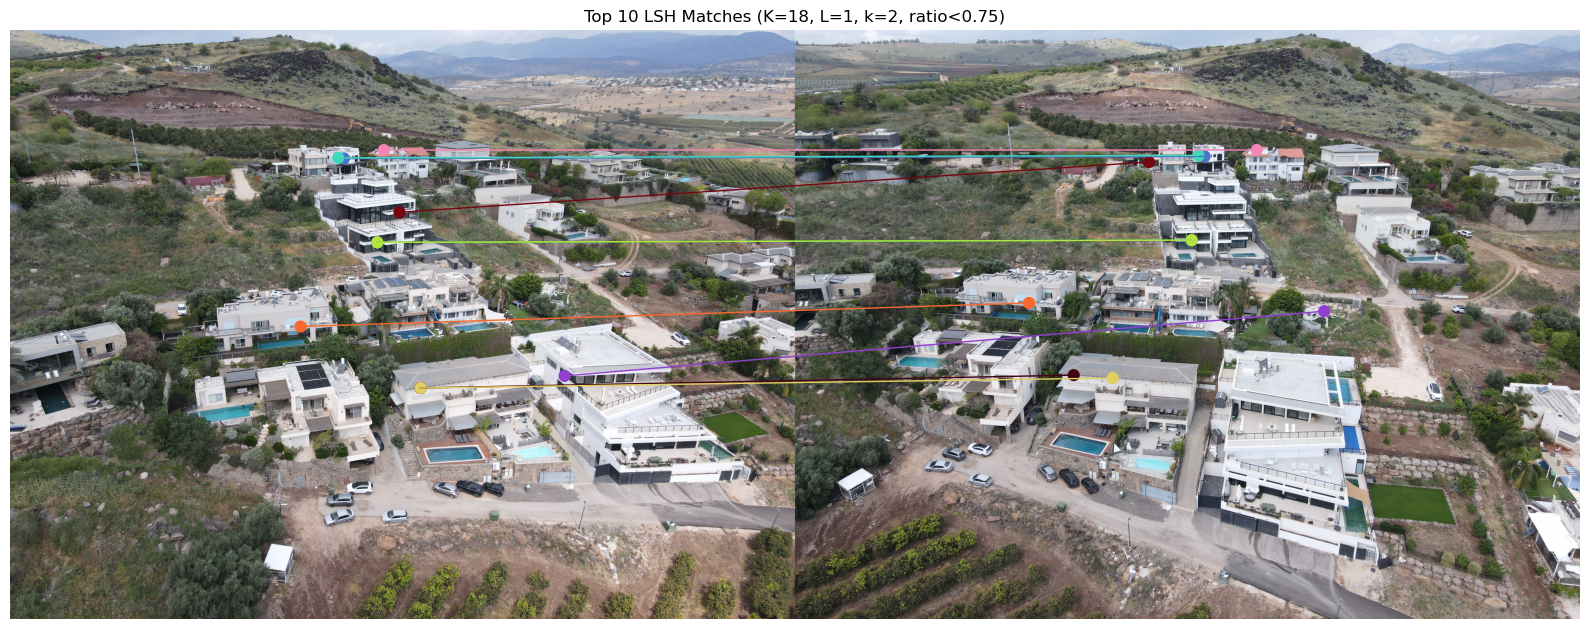

In [685]:

best_model = LSH_ANN(K=int(best_lsh["K"]), L=int(best_lsh["L"]))
best_model.fit(X_train)

indices, dists = best_model.kneighbors(X_test, k=2)

def apply_ratio_test(dists, indices, threshold=0.75):
    accepted_matches = []
    for i in range(len(dists)):
        if len(dists[i]) < 2:
            continue
        d1, d2 = dists[i][0], dists[i][1]
        if d1 / d2 < threshold:
            accepted_matches.append((i, indices[i][0], d1))  
    return accepted_matches

valid_matches = apply_ratio_test(dists, indices, threshold=0.75)

valid_matches.sort(key=lambda x: x[2])  
top_10 = valid_matches[:10]

x1 = sift_df["X"].values
y1 = sift_df["Y"].values
x2 = sift_df2["X"].values
y2 = sift_df2["Y"].values

img1_np = np.array(img)
img2_np = np.array(img2)
combined_img = np.hstack((img1_np, img2_np))

plt.figure(figsize=(16, 8))
plt.imshow(combined_img)
plt.title(f"Top 10 LSH Matches (K={int(best_lsh['K'])}, L={int(best_lsh['L'])}, k=2, ratio<0.75)")

offset = img1_np.shape[1]

for i, train_idx, _ in top_10:
    qx, qy = x2[i] + offset, y2[i]
    tx, ty = x1[train_idx], y1[train_idx]
    color = np.random.rand(3,)
    plt.scatter([tx, qx], [ty, qy], c=[color, color], s=60)
    plt.plot([tx, qx], [ty, qy], color=color, linewidth=1)

plt.axis('off')
plt.tight_layout()
plt.show()

We measure the runtime of exact nearest neighbor search using brute-force KNN with `k=2`.

This provides a baseline runtime to compare against approximate methods like LSH and RKDT.


In [687]:
knn = NearestNeighbors(n_neighbors=2, algorithm='brute')
knn.fit(X_train)
start = time.time()
_, dists_knn = knn.kneighbors(X_test, n_neighbors=2)
knn_runtime = time.time() - start

We compile a summary table comparing the exact KNN baseline with the best LSH and RKDT models based on their runtime and approximation error.

This comparison highlights the trade-offs between accuracy and efficiency for the different nearest neighbor approaches.


In [689]:
comparison_data = [
    ("KNN", "-", "-", knn_runtime, 0.0),
    ("LSH", best_lsh["K"], best_lsh["L"], best_lsh["Runtime (s)"], best_lsh["Error"]),
    ("RKDT", best_rkdt["N0"], best_rkdt["L0"], best_rkdt["Runtime (s)"], best_rkdt["Error"])
]

df_compare = pd.DataFrame(comparison_data, columns=["Model", "K/N0", "L/L0", "Runtime (s)", "Error"])
print(df_compare)

  Model K/N0 L/L0  Runtime (s)     Error
0   KNN    -    -     0.016617  0.000000
1   LSH   18    1     0.844072  0.004151
2  RKDT    2   25     2.497263  0.003980


<br>
We visualize the runtime and approximation error of the exact KNN, best LSH, and best RKDT models using bar plots.

- The runtime comparison is shown on a logarithmic scale to clearly display differences across models.
- The error comparison uses a log scale to better capture variations in approximation accuracy.

These plots provide a clear overview of the trade-offs between speed and accuracy for each model.


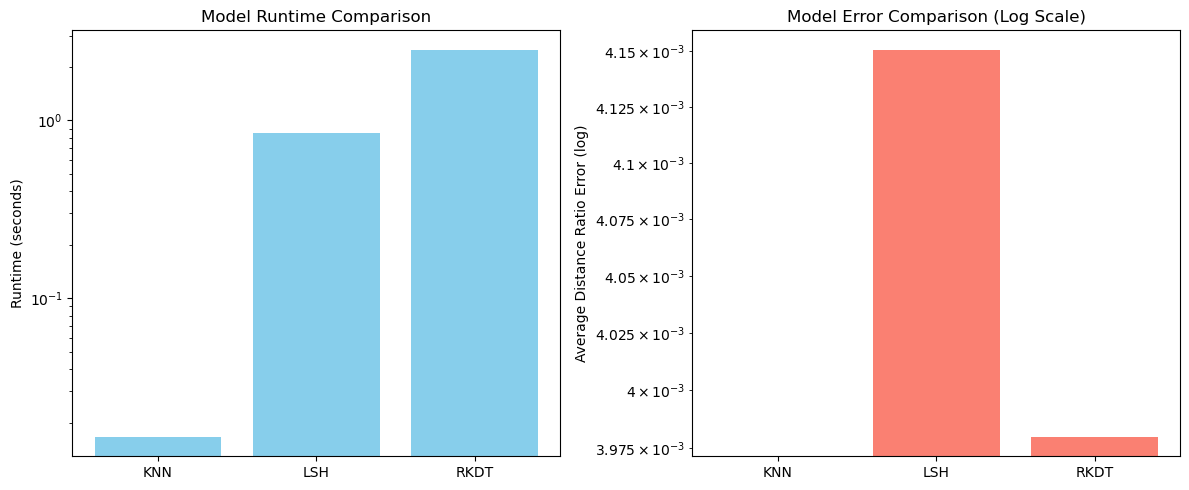

In [691]:
plt.figure(figsize=(12, 5))

df_compare_ = df_compare[df_compare["Model"].isin(["KNN", "LSH", "RKDT"])]


plt.subplot(1, 2, 1)
plt.bar(df_compare_["Model"], df_compare_["Runtime (s)"], color='skyblue')
plt.yscale('log')
plt.title("Model Runtime Comparison")
plt.ylabel("Runtime (seconds)")

plt.subplot(1, 2, 2)
plt.bar(df_compare_["Model"], df_compare_["Error"], color='salmon')
plt.yscale('log')  
plt.title("Model Error Comparison (Log Scale)")
plt.ylabel("Average Distance Ratio Error (log)")

plt.tight_layout()
plt.show()


### Part D: Comparison with sklearn’s KDTree NearestNeighbors

We compare our approximate nearest neighbor models (LSH_ANN and RKDT_ANN) against scikit-learn’s `NearestNeighbors` using the KDTree backend, which provides an exact search baseline optimized for tree-based queries.

For each model, we record:

- **Runtime** of the neighbor search
- **Approximation error ε**, measuring how close the approximate neighbors are to the exact neighbors

This comparison highlights the trade-offs in speed and accuracy between our custom ANN implementations and a well-established exact method.


            Model K/N0 L/L0  Runtime (s)     Error
0             KNN    -    -     0.016617  0.000000
1             LSH   18    1     0.844072  0.004151
2            RKDT    2   25     2.497263  0.003980
3  sklearn_KDTree    -    -     0.497795  0.000000


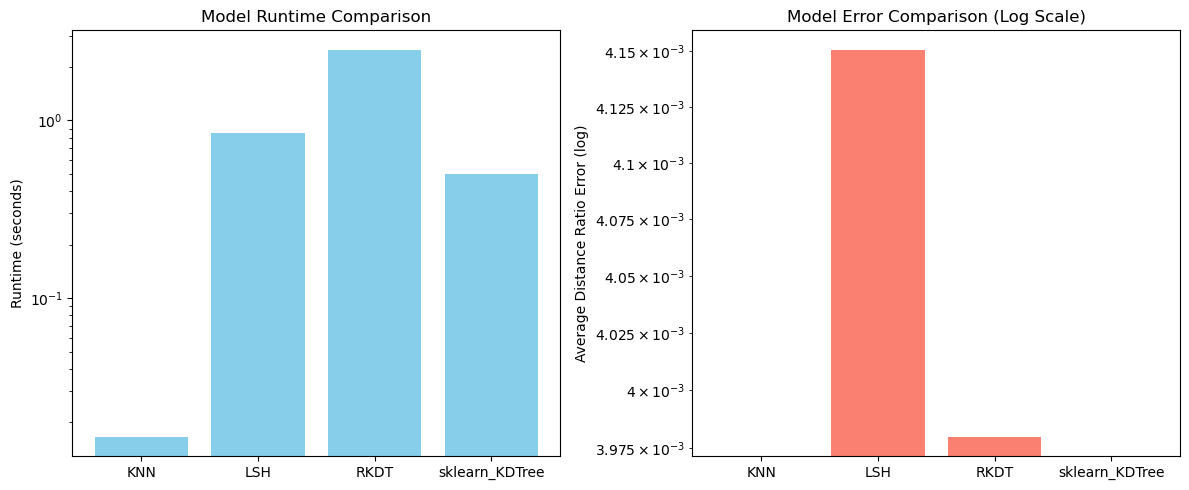

In [693]:
knn_sklearn = NearestNeighbors(n_neighbors=2, algorithm='kd_tree')
knn_sklearn.fit(X_train)

start = time.time()
_, dists_kdtree = knn_sklearn.kneighbors(X_test)
runtime_kdtree = time.time() - start

error_kdtree = 0.0

comparison_dict = {
    "KNN": ("-", "-", knn_runtime, 0.0),
    "LSH": (best_lsh["K"], best_lsh["L"], best_lsh["Runtime (s)"], best_lsh["Error"]),
    "RKDT": (best_rkdt["N0"], best_rkdt["L0"], best_rkdt["Runtime (s)"], best_rkdt["Error"]),
    "sklearn_KDTree": ("-", "-", runtime_kdtree, error_kdtree),
}

df_compare = pd.DataFrame([
    (model, *values) for model, values in comparison_dict.items()
], columns=["Model", "K/N0", "L/L0", "Runtime (s)", "Error"])

print(df_compare)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.yscale('log')
plt.bar(df_compare["Model"], df_compare["Runtime (s)"], color='skyblue')
plt.title("Model Runtime Comparison")
plt.ylabel("Runtime (seconds)")

plt.subplot(1, 2, 2)
plt.yscale('log')
plt.bar(df_compare["Model"], df_compare["Error"], color='salmon')
plt.title("Model Error Comparison (Log Scale)")
plt.ylabel("Average Distance Ratio Error (log)")

plt.tight_layout()
plt.show()

### Part E: Place Recognition 
Parameter Tuning & Prediction Method:

For this task, we implemented a unified predict() method inside both our `LSH_ANN` and `RKDT_ANN` models. Each keypoint in a test image was evaluated by finding its `k` nearest neighbors from the training set. The keypoint was included in the image-level prediction vote only if it passed a set of filters, including:

- **Hard distance threshold** (`threshold = 300`): ignored faraway matches.
- **Ratio test** (`ratio_thresh = 0.8`): eliminated ambiguous matches where the closest two neighbors were similar.
- **Confidence threshold** (`confidence_min_threshold = 0.2`): filtered low-confidence image level predictions.
- **Top response fraction** and **response threshold**: allowed us to use only the most reliable SIFT keypoints (though we kept them all in final settings).

After experimenting, we observed that **LSH and RKDT responded best to slightly different filter combinations**, so we used a separate `PREDICT_PARAMS` dictionary for each model.

**Note**: We implemented the core predict() method for both LSH and RKDT models in Part B, and reused it in Part E with different parameter configurations, as allowed.


In [110]:
PREDICT_PARAMS_LSH = {
    'k': 3,
    'threshold': None,
    'ratio_thresh': 0.8,
    'distance_percentile': 50,
    'response_threshold': 0.0,
    'top_response_fraction': 1.0,
    'min_vote_ratio': 0.0,
    'confidence_min_threshold': 0.2,
    'exclude_labels': {'migdal'},
    'verbose': False
}

PREDICT_PARAMS_RKDT = {
    'k': 3,
    'threshold': 300,
    'ratio_thresh': 0.8,
    'distance_percentile': None,
    'response_threshold': 0.0,
    'top_response_fraction': 1.0,
    'min_vote_ratio': 0.0,
    'confidence_min_threshold': 0.2,
    'exclude_labels': {'migdal'},
    'verbose': False
}


In [111]:
import os

# Define landmark names
landmark_names = [
    "petra", "taj_mahal", "statue_of_liberty", "azrieli_towers", "stonehenge",
    "sydney_opera_house", "christ_the_redeemer", "colosseum", "mount_fuji",
    "mount_rushmore", "pyramids_of_giza"
]

# Load training data
X_train_all = []
y_train_all = []

for name in landmark_names:
    df = pd.read_csv(f"landmarks_sift_datasets/{name}_1_sift_dataset.csv")
    features = df[[col for col in df.columns if "Feature_" in col]].values
    X_train_all.append(features)
    y_train_all.extend([name] * len(features))

X_train_all = np.vstack(X_train_all)
y_train_all = np.array(y_train_all)

# Load test data
X_test_list = []
y_test_list = []
response_list = []

for name in landmark_names:
    df = pd.read_csv(f"landmarks_sift_datasets/{name}_2_sift_dataset.csv")
    features = df[[col for col in df.columns if "Feature_" in col]].values
    responses = df["Response"].values
    X_test_list.append(features)
    response_list.append(responses)
    y_test_list.append(name)

# Load migdal (unknown)
df_migdal = pd.read_csv("migdal_1_sift_dataset.csv")
X_test_list.append(df_migdal[[col for col in df_migdal.columns if "Feature_" in col]].values)
response_list.append(df_migdal["Response"].values)
y_test_list.append("no_match")


In [112]:

lsh_model = LSH_ANN(K=12, L=3)
lsh_model.fit(X_train_all)
np.random.seed(70)
rkdt_model = RKDT_ANN(N0=2, L0=15)
rkdt_model.fit(X_train_all)



In [113]:
# Run predictions for each test image using LSH and RKDT
results_lsh = []
results_rkdt = []

for X_query, responses in zip(X_test_list, response_list):
    pred_lsh, conf_lsh = lsh_model.predict(X_query, y_train_all, PREDICT_PARAMS_LSH, response_scores=responses)
    pred_rkdt, conf_rkdt = rkdt_model.predict(X_query, y_train_all, PREDICT_PARAMS_RKDT, response_scores=responses)
    results_lsh.append((pred_lsh, conf_lsh))
    results_rkdt.append((pred_rkdt, conf_rkdt))

# Separate predictions and confidence scores
y_pred_lsh = [p for p, _ in results_lsh]
conf_lsh = [c for _, c in results_lsh]

y_pred_rkdt = [p for p, _ in results_rkdt]
conf_rkdt = [c for _, c in results_rkdt]


In [114]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

labels = sorted(list(set(y_test_list)))  

# Accuracy and Macro F1
acc_lsh = accuracy_score(y_test_list, y_pred_lsh)
f1_lsh = f1_score(y_test_list, y_pred_lsh, average='macro')

acc_rkdt = accuracy_score(y_test_list, y_pred_rkdt)
f1_rkdt = f1_score(y_test_list, y_pred_rkdt, average='macro')

print(f"LSH Accuracy: {acc_lsh:.3f} | Macro F1: {f1_lsh:.3f}")
print(f"RKDT Accuracy: {acc_rkdt:.3f} | Macro F1: {f1_rkdt:.3f}")


LSH Accuracy: 0.833 | Macro F1: 0.792
RKDT Accuracy: 0.833 | Macro F1: 0.778


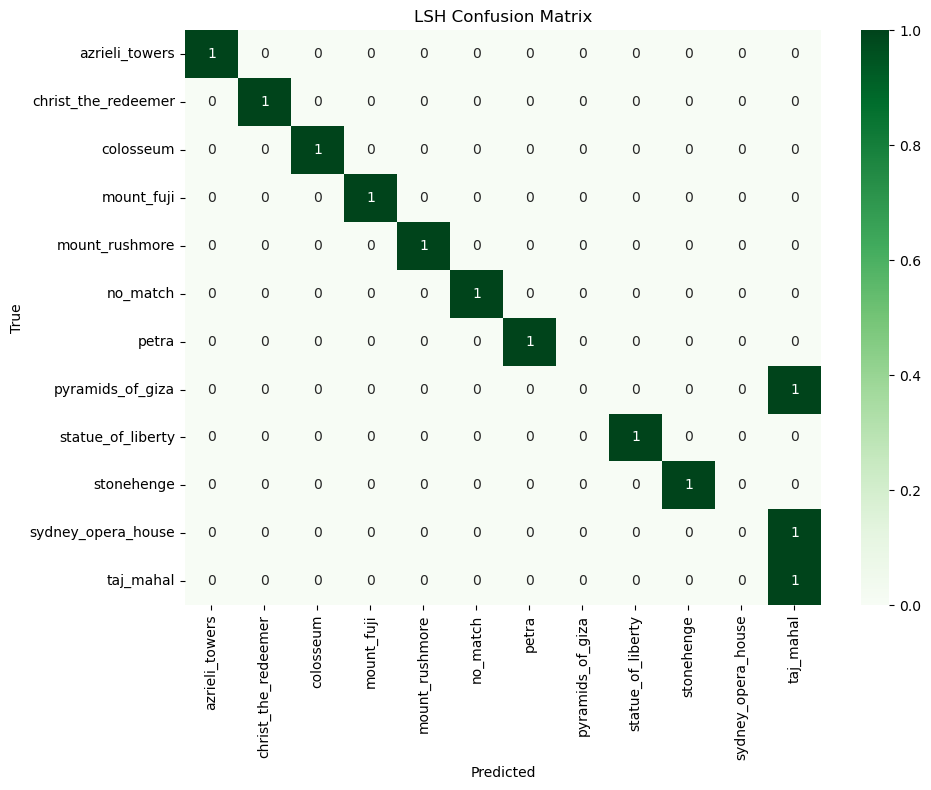

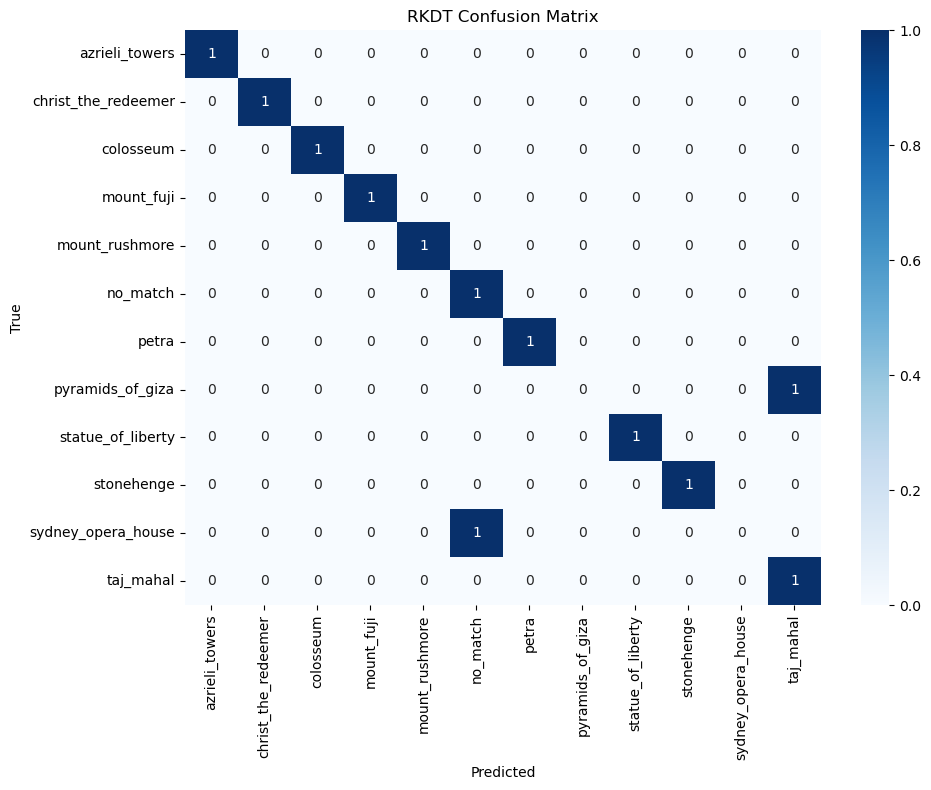

In [115]:
# LSH
cm_lsh = confusion_matrix(y_test_list, y_pred_lsh, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lsh, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Greens")
plt.title("LSH Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# RKDT
cm_rkdt = confusion_matrix(y_test_list, y_pred_rkdt, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rkdt, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("RKDT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [116]:
# LSH results
pd.DataFrame({
    "True Label": y_test_list,
    "Predicted": y_pred_lsh,
    "Confidence": conf_lsh
})


,True Label,Predicted,Confidence
0,petra,petra,0.411765
1,taj_mahal,taj_mahal,0.281250
2,statue_of_liberty,statue_of_liberty,0.437500
3,azrieli_towers,azrieli_towers,1.000000
4,stonehenge,stonehenge,0.939759
5,sydney_opera_house,taj_mahal,0.250000
6,christ_the_redeemer,christ_the_redeemer,0.375000
7,colosseum,colosseum,0.680000
8,mount_fuji,mount_fuji,0.526316
9,mount_rushmore,mount_rushmore,0.555556


In [117]:
# RKDT results
pd.DataFrame({
    "True Label": y_test_list,
    "Predicted": y_pred_rkdt,
    "Confidence": conf_rkdt
})


,True Label,Predicted,Confidence
0,petra,petra,0.309091
1,taj_mahal,taj_mahal,0.231707
2,statue_of_liberty,statue_of_liberty,0.246914
3,azrieli_towers,azrieli_towers,0.812500
4,stonehenge,stonehenge,0.757202
5,sydney_opera_house,no_match,0.174419
6,christ_the_redeemer,christ_the_redeemer,0.250000
7,colosseum,colosseum,0.301370
8,mount_fuji,mount_fuji,0.339623
9,mount_rushmore,mount_rushmore,0.250000


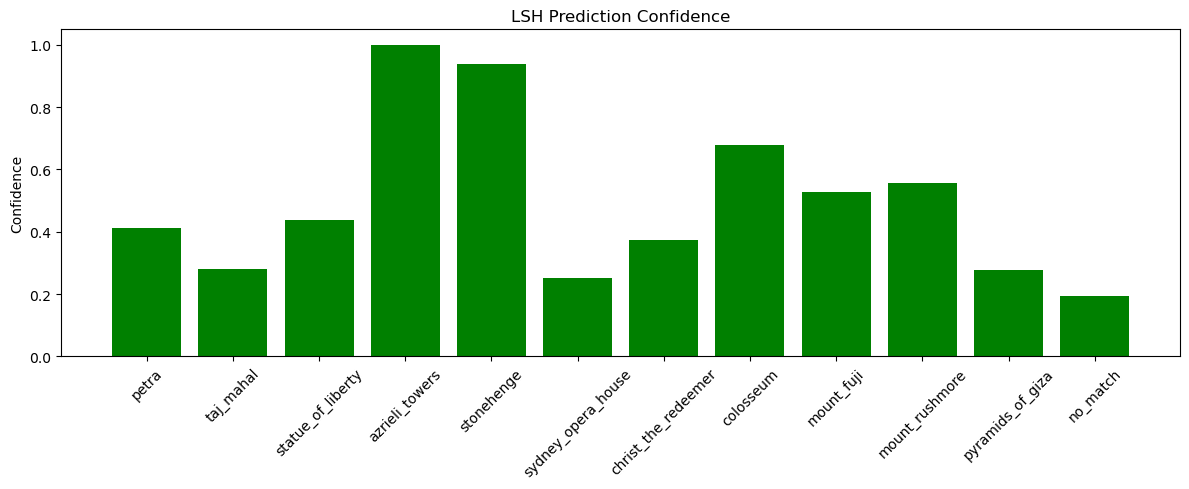

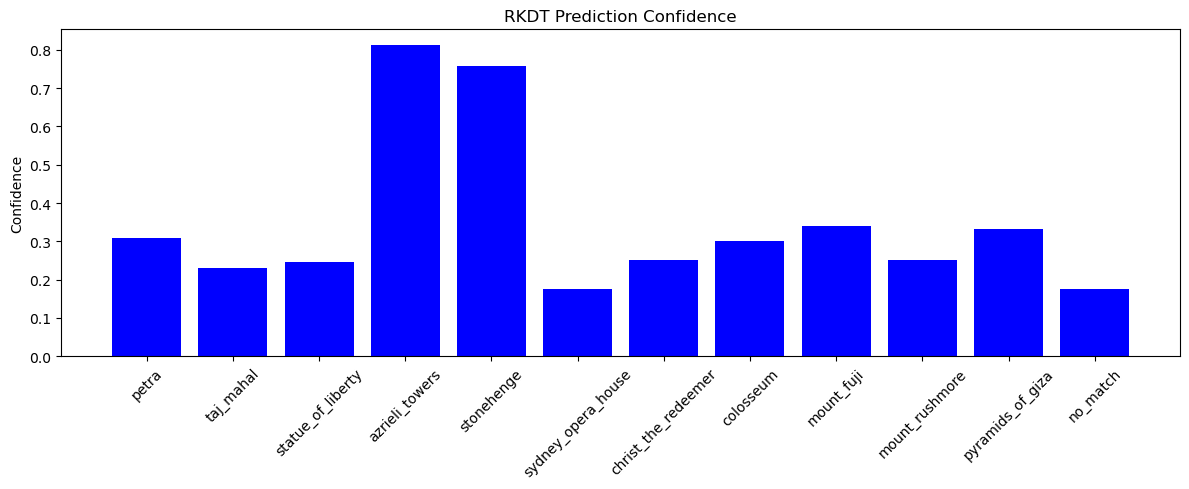

In [118]:
plt.figure(figsize=(12, 5))
plt.bar(range(len(conf_lsh)), conf_lsh, color="green")
plt.xticks(range(len(conf_lsh)), y_test_list, rotation=45)
plt.ylabel("Confidence")
plt.title("LSH Prediction Confidence")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(range(len(conf_rkdt)), conf_rkdt, color="blue")
plt.xticks(range(len(conf_rkdt)), y_test_list, rotation=45)
plt.ylabel("Confidence")
plt.title("RKDT Prediction Confidence")
plt.tight_layout()
plt.show()


###  Tuning k and Confidence Threshold 
We began by exploring how varying `k` and the `confidence_min_threshold` alone would affect model performance.
This allowed us to observe baseline accuracy without advanced filtering or ratio tests.
Despite some gains (accuracy = 0.58 for k=2 and conf=0.1), these settings alone were insufficient for optimal place recognition. we concluded that it is more effecient to include a ratio test 

In [129]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Grid of shared parameters
param_grid = {
    'k': [2, 3],
    'threshold': [250, 300],
    'confidence_min_threshold': [0.2, 0.3]
}

# Generate all combinations
grid = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())
results = []

# Refit models once
np.random.seed(70)
lsh_model = LSH_ANN(K=12, L=3)
lsh_model.fit(X_train_all)

np.random.seed(70)
rkdt_model = RKDT_ANN(N0=2, L0=15)
rkdt_model.fit(X_train_all)

# Loop through each config and evaluate both WITH and WITHOUT ratio test
for i, combo in enumerate(grid):
    config = dict(zip(param_names, combo))
    print(f"🔄 Testing config {i+1}/{len(grid)}: {config}")

    for ratio_setting in [None, 0.8]:  # ⛔ OFF and ✅ ON
        ratio_label = "None" if ratio_setting is None else "0.8"
        
        PREDICT_PARAMS = {
            'k': config['k'],
            'threshold': config['threshold'],
            'ratio_thresh': ratio_setting,
            'distance_percentile': None,
            'response_threshold': 0.0,
            'top_response_fraction': 1.0,
            'min_vote_ratio': 0.0,
            'confidence_min_threshold': config['confidence_min_threshold'],
            'exclude_labels': {'migdal'},
            'verbose': False
        }

        # LSH
        y_pred_lsh = []
        for X_query, responses in zip(X_test_list, response_list):
            pred, _ = lsh_model.predict(X_query, y_train_all, PREDICT_PARAMS, response_scores=responses)
            y_pred_lsh.append(pred)
        acc_lsh = accuracy_score(y_test_list, y_pred_lsh)
        f1_lsh = f1_score(y_test_list, y_pred_lsh, average='macro')

        # RKDT
        y_pred_rkdt = []
        for X_query, responses in zip(X_test_list, response_list):
            pred, _ = rkdt_model.predict(X_query, y_train_all, PREDICT_PARAMS, response_scores=responses)
            y_pred_rkdt.append(pred)
        acc_rkdt = accuracy_score(y_test_list, y_pred_rkdt)
        f1_rkdt = f1_score(y_test_list, y_pred_rkdt, average='macro')

        results.append({
            **config,
            'Ratio_Test': ratio_label,
            'LSH_Accuracy': acc_lsh,
            'LSH_F1': f1_lsh,
            'RKDT_Accuracy': acc_rkdt,
            'RKDT_F1': f1_rkdt
        })

# Display combined result table
results_df = pd.DataFrame(results).sort_values(by='RKDT_F1', ascending=False).reset_index(drop=True)
display(results_df.head(20))


🔄 Testing config 1/8: {'k': 2, 'threshold': 250, 'confidence_min_threshold': 0.2}
🔄 Testing config 2/8: {'k': 2, 'threshold': 250, 'confidence_min_threshold': 0.3}
🔄 Testing config 3/8: {'k': 2, 'threshold': 300, 'confidence_min_threshold': 0.2}
🔄 Testing config 4/8: {'k': 2, 'threshold': 300, 'confidence_min_threshold': 0.3}
🔄 Testing config 5/8: {'k': 3, 'threshold': 250, 'confidence_min_threshold': 0.2}
🔄 Testing config 6/8: {'k': 3, 'threshold': 250, 'confidence_min_threshold': 0.3}
🔄 Testing config 7/8: {'k': 3, 'threshold': 300, 'confidence_min_threshold': 0.2}
🔄 Testing config 8/8: {'k': 3, 'threshold': 300, 'confidence_min_threshold': 0.3}


,k,threshold,confidence_min_threshold,Ratio_Test,LSH_Accuracy,LSH_F1,RKDT_Accuracy,RKDT_F1
0,2,300,0.2,0.8,0.750000,0.680556,0.833333,0.777778
1,3,300,0.2,0.8,0.750000,0.680556,0.833333,0.777778
2,2,250,0.2,0.8,0.750000,0.680556,0.666667,0.611111
3,3,250,0.2,0.8,0.750000,0.680556,0.666667,0.611111
4,2,250,0.3,0.8,0.583333,0.500000,0.583333,0.527778
5,3,250,0.3,0.8,0.583333,0.500000,0.583333,0.527778
6,2,250,0.2,None,0.250000,0.181818,0.583333,0.500000
7,3,250,0.2,None,0.250000,0.181818,0.583333,0.500000
8,2,300,0.3,0.8,0.583333,0.500000,0.500000,0.440476
9,3,300,0.3,0.8,0.583333,0.500000,0.500000,0.440476


## Summary of Our Approach

In this task, we trained two approximate nearest neighbor models (LSH and RKDT) on SIFT descriptors extracted from the 11 landmark images. Each test image (including the unknown `migdal_1`) was then classified based on keypoint-level voting using these trained models.

We implemented a flexible and modular `predict()` method inside both models, allowing us to tune the filtering criteria via a shared `PREDICT_PARAMS` dictionary. We explored various combinations of `k`, confidence thresholds, ratio tests, and distance filters.

Key points in our solution:
- We used **majority voting** from valid keypoints to classify each test image.
- If the predicted label had **low confidence**, or the match quality was poor, the model returned `"no_match"`.
- We validated model performance using both **accuracy** and **macro F1**, as well as confusion matrices and confidence visualizations.

  Final Results:
- LSH Accuracy: 83.3%, Macro F1: 0.792
- RKDT Accuracy: 83.3%, Macro F1: 0.778

Our model successfully identified the unknown migdal_1 as "no_match" and correctly classified most landmarks with high confidence, fulfilling the task’s goals.

